In [96]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [97]:
#Define the positive and negative classes
positive_points=np.array([(-2,3),(0,1),(2,-1)])
negative_points=np.array([(-2,1),(0,-1),(2,-3)])

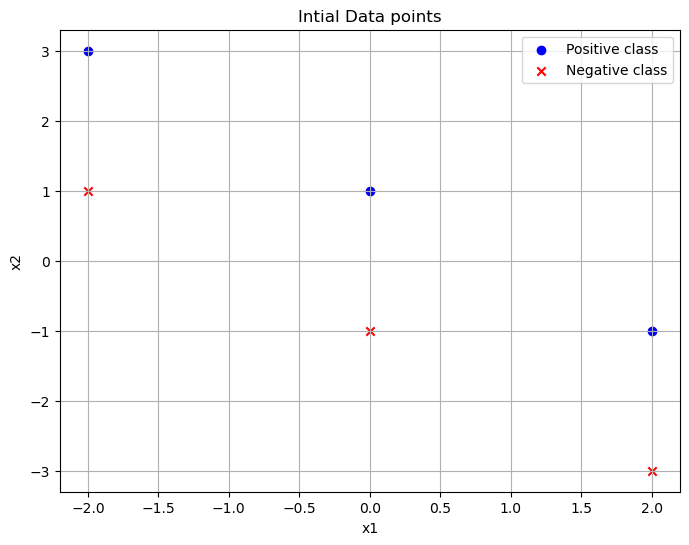

In [98]:
#plot initial data points
plt.figure(figsize=(8,6))
plt.scatter(positive_points[:,0], positive_points[:,1], color='blue', marker='o', label="Positive class")
plt.scatter(negative_points[:,0], negative_points[:,1], color='red', marker='x', label="Negative class")
plt.legend(loc='best')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title("Intial Data points")
plt.grid(True)
plt.show()



In [99]:
#Combine all points and labels
X=np.vstack((positive_points, negative_points))
y=np.array([1]*len(positive_points)+[-1]*len(negative_points))

In [100]:
X

array([[-2,  3],
       [ 0,  1],
       [ 2, -1],
       [-2,  1],
       [ 0, -1],
       [ 2, -3]])

In [ ]:
y #classification

array([ 1,  1,  1, -1, -1, -1])

In [102]:
#Perceptron algorithm
def perceptron(X,y,steps=10):
    theta=np.zeros(X.shape[1])
    theta0=0
    for j in range(steps):
        for i, xi in enumerate(X):
            if y[i]*(np.dot(xi,theta)+theta0)<=0:
                theta +=y[i]*xi
                theta0+=y[i]
                break
                
        #Plot for each iteration
        plot_decision_boundary(theta, theta0, j+1)
    return theta, theta0
 
    
    

In [103]:
def plot_decision_boundary(theta, theta0, iteration):
    plt.figure(figsize=(8,6))
    plt.scatter(positive_points[:,0], positive_points[:,1], color='blue', label="Positive class")
    plt.scatter(negative_points[:,0], negative_points[:,1], color='red', label="Negative class")

    #plot decision boundary
    x_values=np.linspace(-3,3,2)

    # check for theta[1] yo avoid division by zero of vertical line
    if theta[1] !=0:
        y_values=-(theta[0]*x_values+theta0)/theta[1]
        plt.plot(x_values, y_values, label=f'Iteration {iteration}')
    else:
        #plot vertical line
        x_val=-theta0/theta[0]
        plt.axvline(x=x_val, label=f'iteration{iteration}')

    plt.xlim(-3,3)
    plt.ylim(-4,4)
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.title(f'Decision Boundary at Iteration {iteration}')
    plt.legend()
    plt.savefig("Decision_Boundary_over_iterations.png")
    plt.grid(True)
    plt.show()

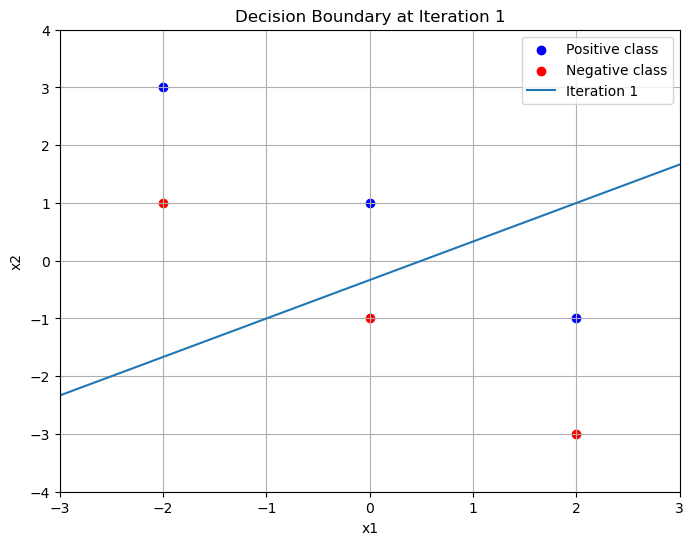

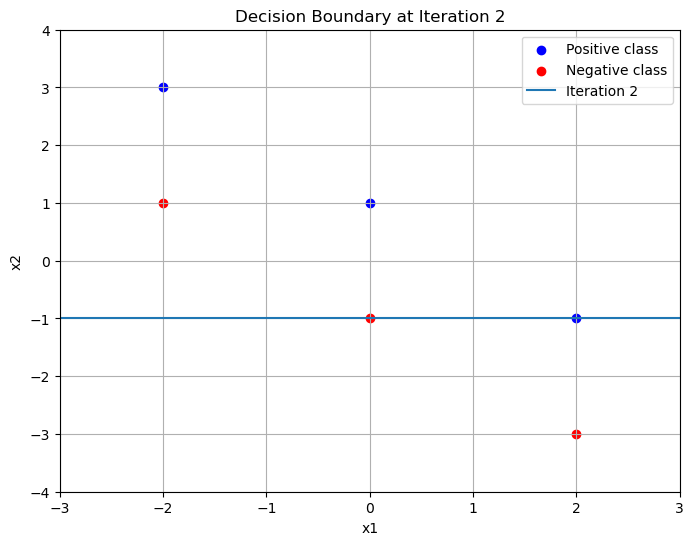

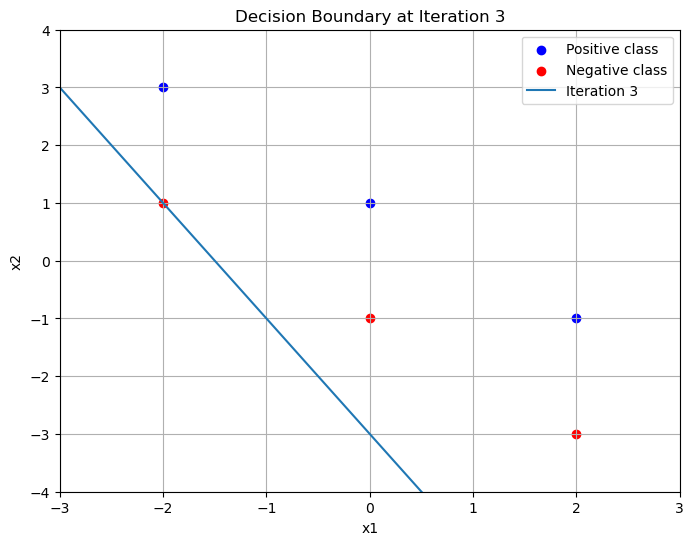

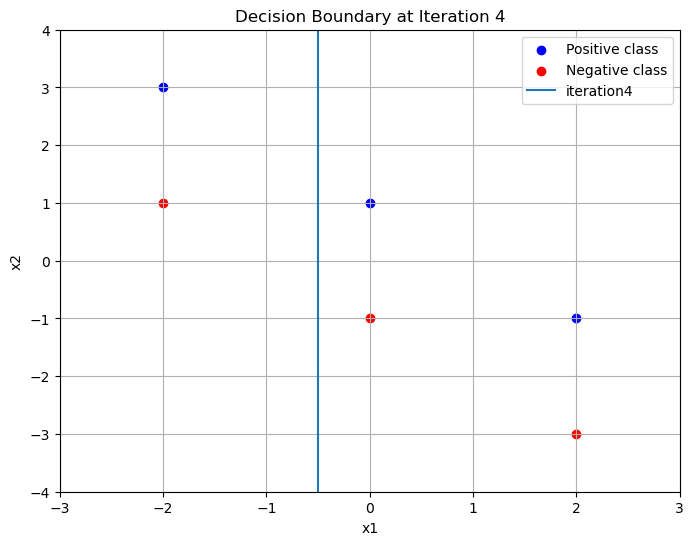

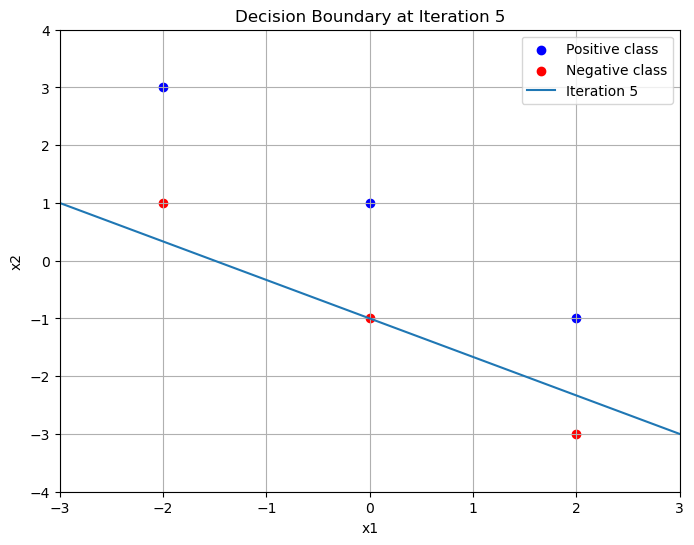

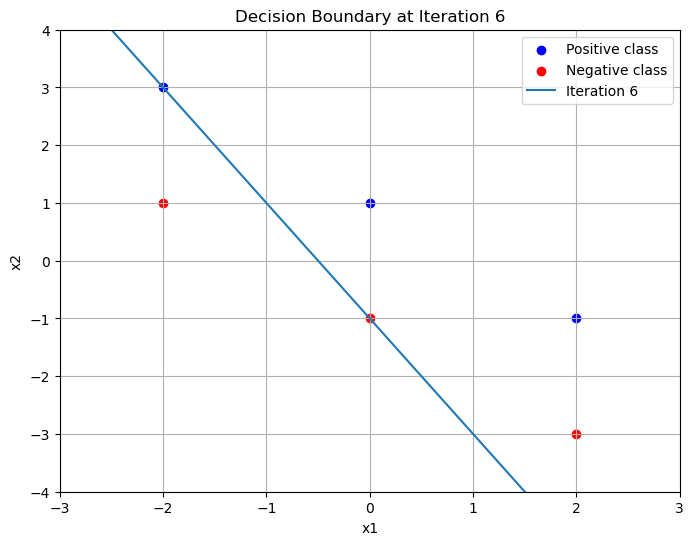

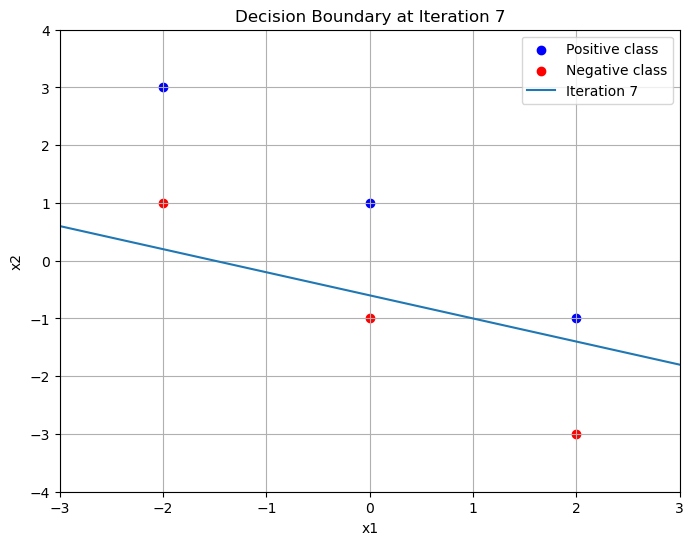

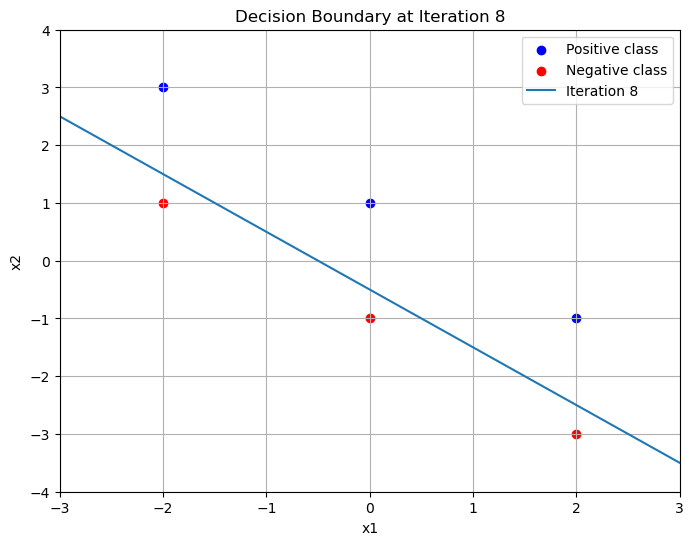

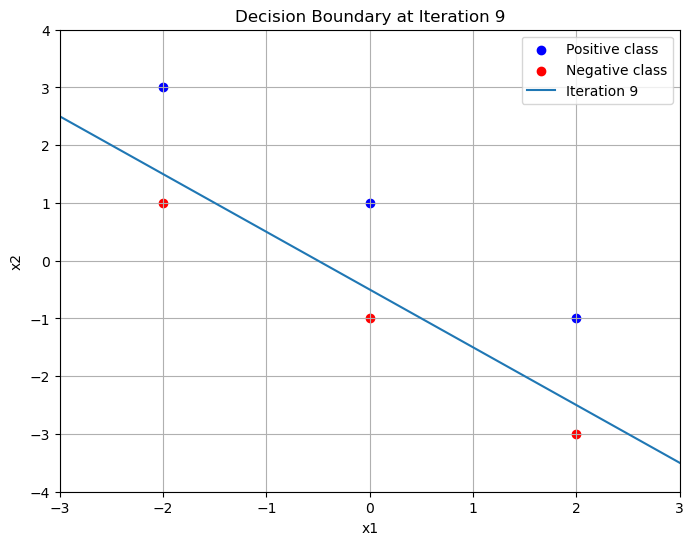

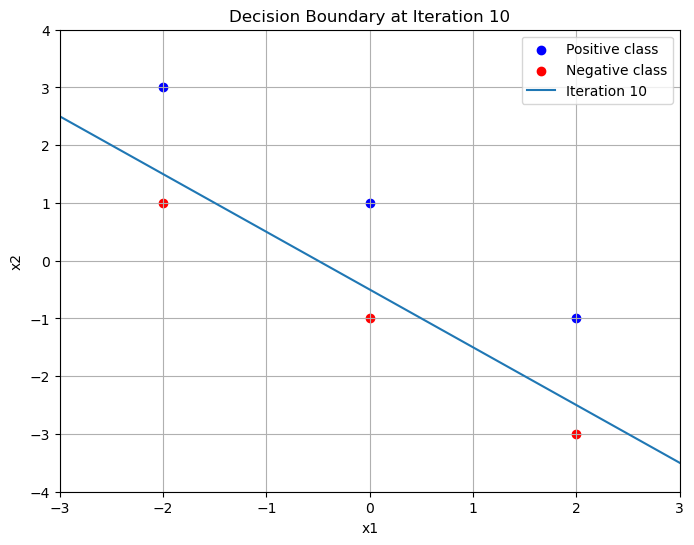

In [104]:
theta_final, theta0_final=perceptron(X,y,10)